In [1]:
%load_ext autoreload

In [3]:
%autoreload 2
# import libraries
import glob
import sys
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import matplotlib.patches as patches
import cv2 as cv

In [4]:
# Help there: https://gist.github.com/izikeros/e81139612102dbda5725cdfb102ada41
# add the repo where lightglue is installed to sys.path
lightglue_repo_path = "/Users/fsudre/Desktop/PROJECTS/PathologyRegistrationPipeline/LightGlue/"
if lightglue_repo_path not in sys.path:
    sys.path.append(lightglue_repo_path)

In [5]:
from lightglue import LightGlue, SuperPoint, DISK, SIFT, ALIKED, DoGHardNet
from lightglue.utils import load_image, rbd
from lightglue import viz2d

/Users/fsudre/Desktop/PROJECTS/PathologyRegistrationPipeline/LightGlue/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


## Open both slices

In [4]:
slide_path = "../data/meninges/"

slide_1_filename = "GWIN2000662_2221.tif"
slide_2_filename = "GWIN2000662_2222.tif"


In [5]:
slide_1 = cv.imread(slide_path + slide_1_filename, 
                    #cv.IMREAD_GRAYSCALE,
                    cv.IMREAD_UNCHANGED)
slide_2 = cv.imread(slide_path + slide_2_filename, 
                    #cv.IMREAD_GRAYSCALE
                    cv.IMREAD_UNCHANGED)

In [6]:
def plot_slide_from_file(path_n_filename):
    slide_img = cv.imread(path_n_filename, cv.IMREAD_GRAYSCALE)
    slide_img_title = path_n_filename.split('/')[-1]
    plt.imshow(slide_img, cmap='Greys_r')
    plt.title(slide_img_title)
    plt.colorbar()

In [7]:
def plot_slide_from_array(array):
    plt.imshow(array, cmap='Greys_r')
    plt.colorbar()

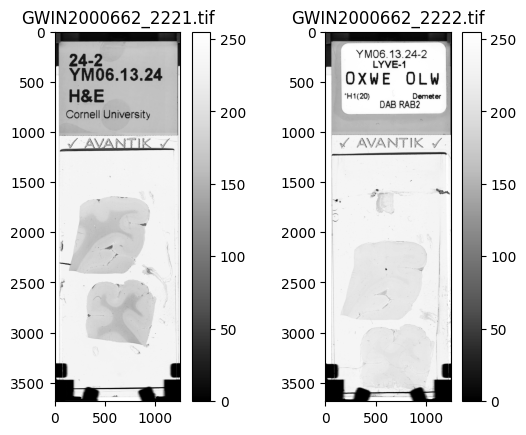

In [8]:
plt.figure()
plt.subplot(1,2,1)
plot_slide_from_file(slide_path + slide_1_filename)
plt.subplot(1,2,2)
plot_slide_from_file(slide_path + slide_2_filename)

## Extract regions of interest

Text(0.5, 1.0, 'GWIN2000662_2222.tif')

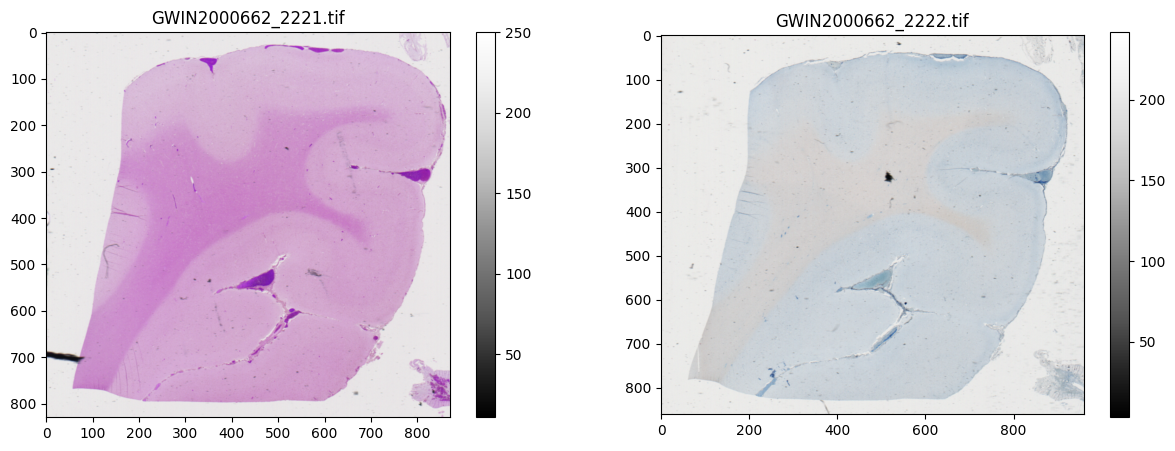

In [9]:
cropped_1 = slide_1[1620:2450,80:950]
cropped_2 = slide_2[2050:2910,90:1050]

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plot_slide_from_array(cropped_1)
plt.title(slide_1_filename)
plt.subplot(1,2,2)
plot_slide_from_array(cropped_2)
plt.title(slide_2_filename)

In [10]:
# save cropped but unprocessed image
filename_1_cropped = slide_1_filename.split(".")[0]+"_top_unprocessed.tif"
filename_2_cropped = slide_2_filename.split(".")[0]+"_top_unprocessed.tif"

cv.imwrite(slide_path + filename_1_cropped, cropped_1)
cv.imwrite(slide_path + filename_2_cropped, cropped_2)

True

## Improve contrast


Text(0.5, 1.0, 'GWIN2000662_2222.tif')

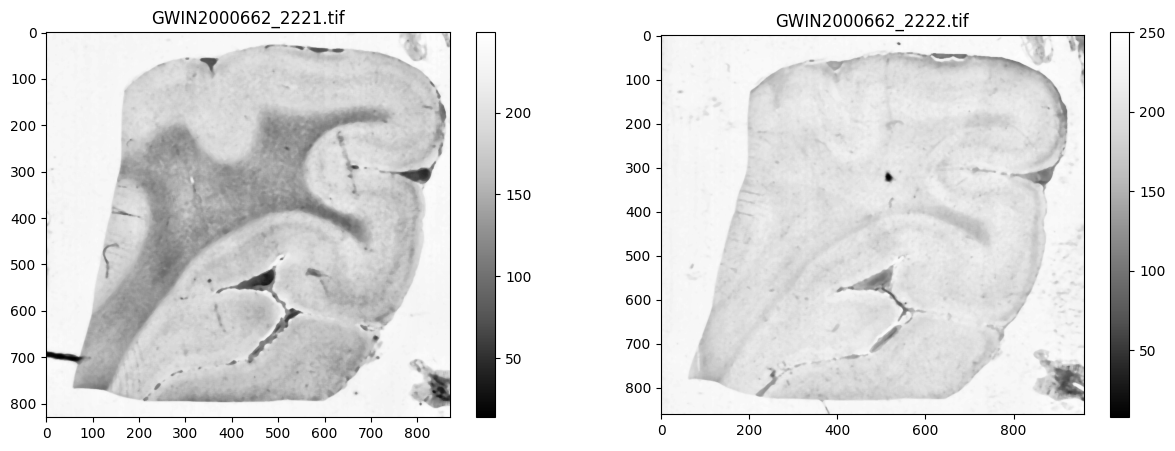

In [12]:
# CLAHE: Contrast Limited Adaptive Histogram Equalization)
# improves local contrast and enhances the definition of edges in images.
clahe = cv.createCLAHE(clipLimit=5.0, tileGridSize=(10, 10))
better_img_1 = clahe.apply(cv.medianBlur(cropped_1, ksize=7))
better_img_2 = clahe.apply(cv.medianBlur(cropped_2, ksize=7))

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plot_slide_from_array(better_img_1)
plt.title(slide_1_filename)
plt.subplot(1,2,2)
plot_slide_from_array(better_img_2)
plt.title(slide_2_filename)

In [13]:
filename_1_cropped = slide_1_filename.split(".")[0]+"_top_processed.tif"
filename_2_cropped = slide_2_filename.split(".")[0]+"_top_processed.tif"

cv.imwrite(slide_path + filename_1_cropped, better_img_1)
cv.imwrite(slide_path + filename_2_cropped, better_img_2)

True

## Alignment with LightGlue

In [14]:
# SuperPoint+LightGlue
#extractor = SuperPoint(max_num_keypoints=2048).eval().cuda()  # load the extractor
#matcher = LightGlue(features='superpoint').eval().cuda()  # load the matcher

# or DISK+LightGlue, ALIKED+LightGlue or SIFT+LightGlue
extractor = SIFT(max_num_keypoints=2048)  #.eval()  # load the extractor
matcher = LightGlue(features='disk') #.eval()  # load the matcher


In [15]:
# load each image as a torch.Tensor on GPU with shape (3,H,W), normalized in [0,1]
image0 = load_image(slide_path + filename_1_cropped)
image1 = load_image(slide_path + filename_2_cropped)

In [16]:
# extract local features
feats0 = extractor.extract(image0)  # auto-resize the image, disable with resize=None
feats1 = extractor.extract(image1)

In [17]:
# match the features
matches01 = matcher({'image0': feats0, 'image1': feats1})
feats0, feats1, matches01 = [rbd(x) for x in [feats0, feats1, matches01]]  # remove batch dimension
matches = matches01['matches']  # indices with shape (K,2)
points0 = feats0['keypoints'][matches[..., 0]]  # coordinates in image #0, shape (K,2)
points1 = feats1['keypoints'][matches[..., 1]]  # coordinates in image #1, shape (K,2)

In [18]:
kpts0, kpts1, matches = feats0["keypoints"], feats1["keypoints"], matches01["matches"]
m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]]

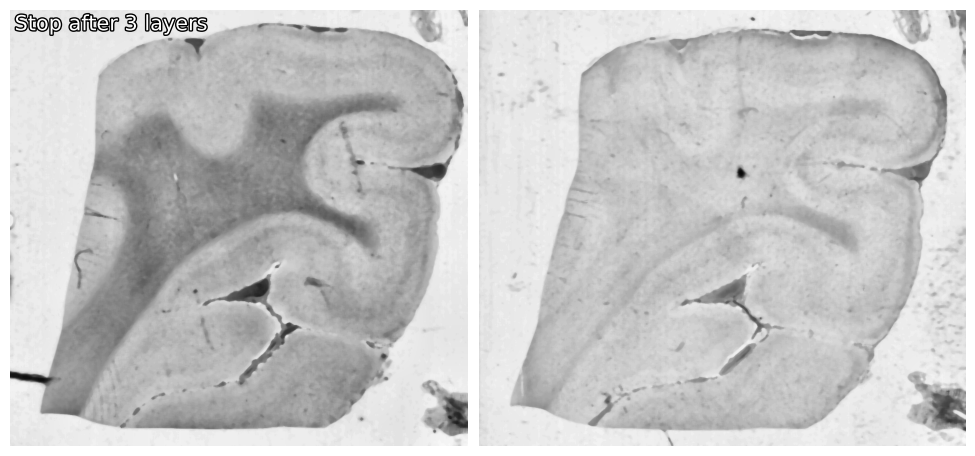

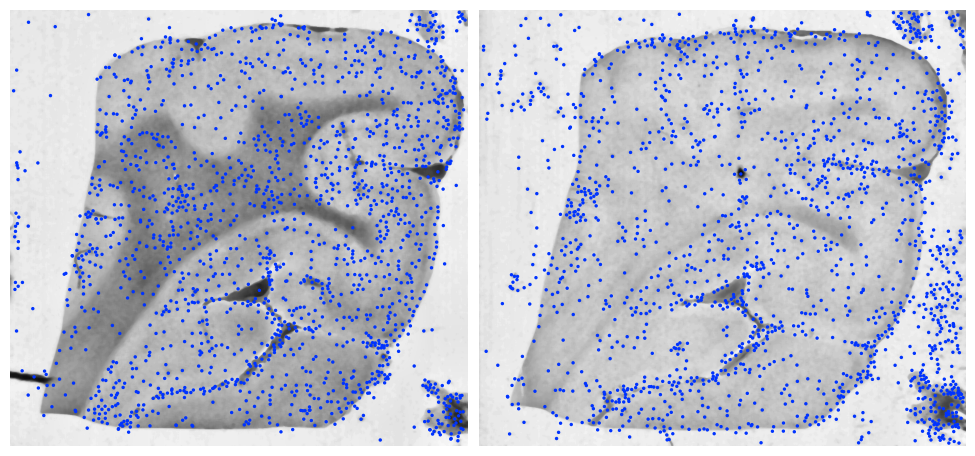

In [19]:
axes = viz2d.plot_images([image0, image1])
viz2d.plot_matches(m_kpts0, m_kpts1, color="lime", lw=0.2)
viz2d.add_text(0, f'Stop after {matches01["stop"]} layers')

kpc0, kpc1 = viz2d.cm_prune(matches01["prune0"]), viz2d.cm_prune(matches01["prune1"])
viz2d.plot_images([image0, image1])
viz2d.plot_keypoints([kpts0, kpts1], colors=[kpc0, kpc1], ps=6)

## Next steps
- better contrast to distinguish the white matter
    - try histology image pre-processing from this: https://github.com/BiomedSciAI/histocartography

- mask the background


In [23]:
matches01

{'matches0': tensor([-1, -1, -1,  ..., -1, -1, -1]),
 'matches1': tensor([-1, -1, -1,  ..., -1, -1, -1]),
 'matching_scores0': tensor([0., 0., 0.,  ..., 0., 0., 0.], grad_fn=<SelectBackward0>),
 'matching_scores1': tensor([0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 6.5805e-05, 0.0000e+00,
         3.9825e-06], grad_fn=<SelectBackward0>),
 'stop': 3,
 'matches': tensor([], size=(0, 2), dtype=torch.int64),
 'scores': tensor([], grad_fn=<IndexBackward0>),
 'prune0': tensor([3, 3, 3,  ..., 3, 3, 3]),
 'prune1': tensor([3, 3, 3,  ..., 3, 3, 3])}